In [ ]:
from bloqade.analog import load, save
from bloqade.analog.atom_arrangement import Square
import numpy as np
import os
import matplotlib.pyplot as plt
from bloqade.analog import get_capabilities


from bokeh.io import output_notebook
output_notebook() 

if not os.path.isdir("data"):
    os.mkdir("data")

# setting the seed
rng = np.random.default_rng(1234)
# a=5
# lattice =Square(4, lattice_spacing=a).apply_defect_density(0.3, rng=rng).remove_vacant_sites()

from bloqade.analog import start



def run_rydberg(points):
    geometry = start.add_position(points)

    #durations = [0.3, 1.6, 0.3]

    # lattice.show()
    # geometry.show()

    # get capabilities for Aquila
    aquila_capabilities = get_capabilities()

    C6=float(aquila_capabilities.capabilities.rydberg.c6_coefficient)
    Omega_max= float(aquila_capabilities.capabilities.rydberg.global_.rabi_frequency_max) #2*np.pi*4 #

    Rba=np.power(2,3/4)
    Rb=Rba*a
    print(Rb)
    # Rb=12

    Delta_end= (C6)/Rb**6 #final detuning 2*np.pi*11

    RbO=(C6/Omega_max)**(1/6)
    RbD=(C6/Delta_end)**(1/6)

    from bloqade.analog import piecewise_linear

    T_max=4
    sweep_time = 0.8*T_max #time length of the protocol 
    ramp_time=0.1*T_max

    rabi_amplitude_values = [0.0, Omega_max, Omega_max, 0.0]
    detuning_values = [-Delta_end, -Delta_end, Delta_end, Delta_end]
    durations = [ramp_time, sweep_time, ramp_time]

    RabiProtocol = piecewise_linear(durations,rabi_amplitude_values)
    DeltaProtocol = piecewise_linear(durations,detuning_values)

    # RabiProtocol.show()
    # DeltaProtocol.show()

    mis_udg_program=(
            # lattice.rydberg.rabi.amplitude.uniform.apply(RabiProtocol)
            # .detuning.uniform.apply(DeltaProtocol)
            geometry.rydberg.rabi.amplitude.uniform.apply(RabiProtocol).detuning.uniform.apply(DeltaProtocol)
    )

    result = mis_udg_program.bloqade.python().run(100,interaction_picture=True)

    report = result.report()
    # report.show()

    data = result.report().bitstrings()

    temp = [0]*len(points)
    for i in range(len(data[0])):
        temp += data[0][i]

    # make values greater than 50 into 1, and less than 50 into 0
    # temp = [1 if x > 8200 else 0 for x in temp]
    temp = [float(x/10000) for x in temp]
    temp

    bitstrings, counts = np.unique(data[0], axis=0, return_counts=True)

    #plot countsof each uniqu bitstring
    # plt.bar(range(len(counts)), counts)
    # plt.xlabel('Bitstring')
    # plt.ylabel('Counts')
    # plt.title('Counts of each unique bitstring')
    # plt.show()


    #get index of the maximum value in counts
    max = bitstrings[np.argmax(counts)]
    inv = [1 if x == 0 else 0 for x in max]
    # make a dictionary mapping the values in env to their sam indexed coordinates in points
    mapping = {i: points[i] for i in range(len(points))}
    mapping

    # inv 
    print(points)
    print(inv)

    max_set = [cordinate for i, cordinate in enumerate(points) if inv[i] == 1]
    remaining_set = [cordinate for i, cordinate in enumerate(points) if inv[i] == 0]

    if not max_set:
        max_set = remaining_set
        remaining_set = []

    return remaining_set, max_set


Loading BokehJS ...

In [35]:
np.power(2,3/4)

np.float64(1.681792830507429)

# Main

In [ ]:
a = 5
# a = 1 # a;ready scaled here

# mul;tiply all the points x5 
og_points = [(8,  5),  (7,  4),  (5,  4), (8,  3),  (4,  3),  (7,  3), (5,  2), (3,  2),  (7,  2),  (2,  2), (6,  3), (4,  1), (1,  1), (3,  1), (2,  0), (0,  0)]
og_points =  [(8, 0), (7, 1), (5, 1), (8, 2), (4, 2), (7, 2),(5, 3), (3, 3), (7, 3), (2, 3), (6, 2), (4, 4),(1, 4), (3, 4), (2, 5), (0, 5)]
# og_points = [(0, 8), (1, 8), (3, 6), (4, 4), (4, 7), (5, 7), (6, 7), (9, 7), (8, 6), (7, 5), (9, 4), (9, 2), (9, 5), (10, 0), (5, 2), (6, 4)]
og_points =[(0, 7),(1, 7),(2, 6),(3, 4),(3, 7),(4, 7),(5, 7),(8, 7),(7, 6),(6, 5),(8, 4),(8, 2),(8, 5),(8, 0),(4, 2),(5, 4)]



og_points = [(x*a,y*a) for x,y in og_points] #TODO add back

points = og_points.copy()
coloring = []

while points:
    remaining_set, max_set = run_rydberg(points)
    points = remaining_set
    coloring.append(max_set)

# plot then colored graph
# fig, ax = plt.subplots()
print(coloring)
visualize_colored_groups(coloring)

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


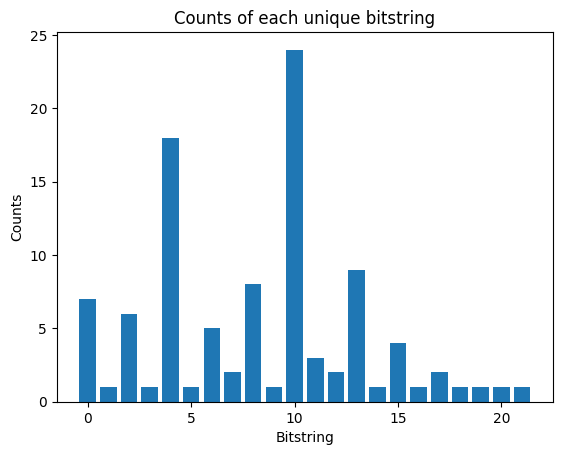

[(10, 10), (15, 15), (15, 15), (5, 0), (10, 15), (0, 15), (10, 5), (5, 5), (10, 5)]
[0, 0, 1, 1, 0, 1, 0, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


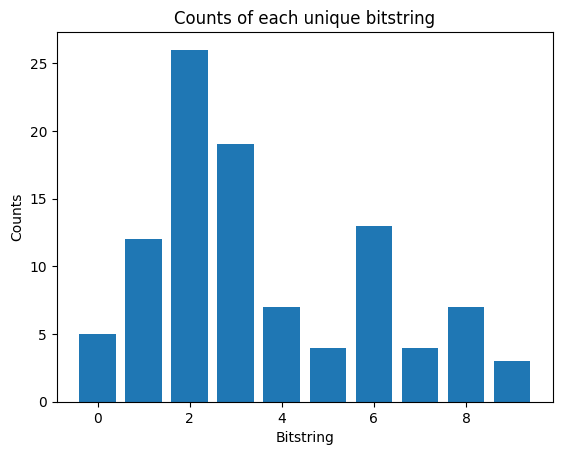

[(10, 10), (15, 15), (10, 15), (10, 5), (5, 5), (10, 5)]
[0, 1, 0, 0, 1, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


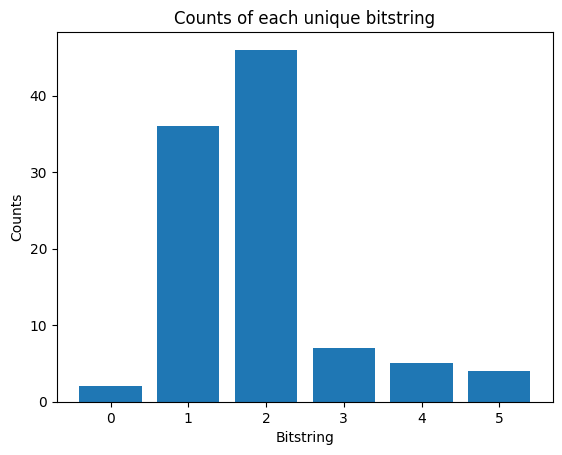

[(10, 10), (10, 15), (10, 5), (10, 5)]
[0, 1, 0, 1]
8.408964152537145


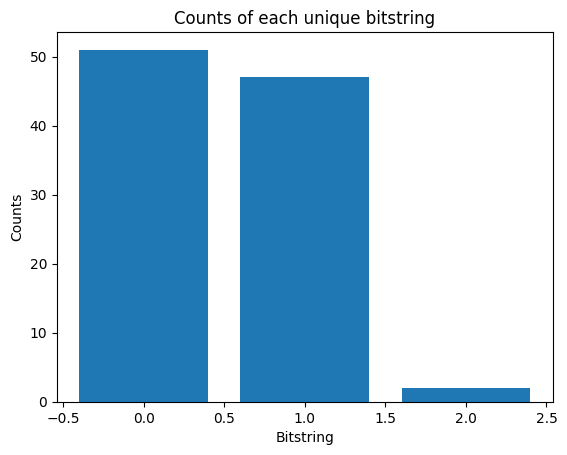

[(10, 10), (10, 5)]
[1, 0]
8.408964152537145


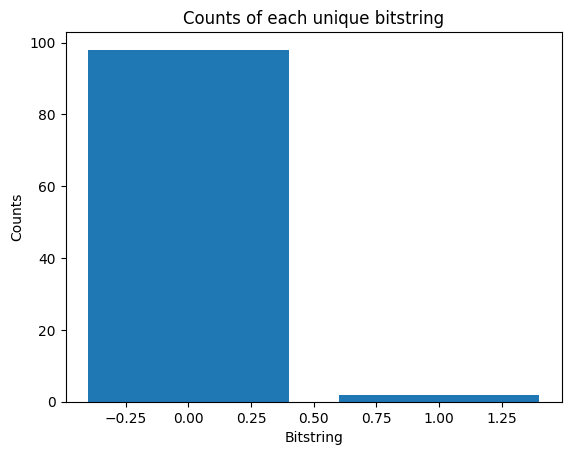

[(10, 5)]
[1]
[[(15, 15), (5, 0), (0, 15)], [(15, 15), (5, 5)], [(10, 15), (10, 5)], [(10, 10)], [(10, 5)]]


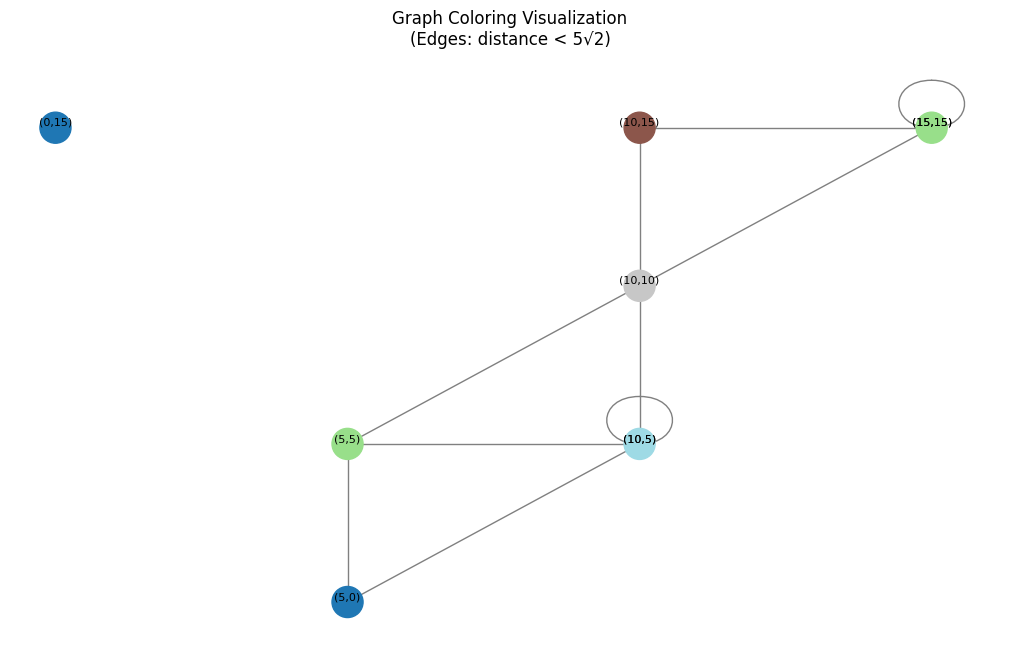

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


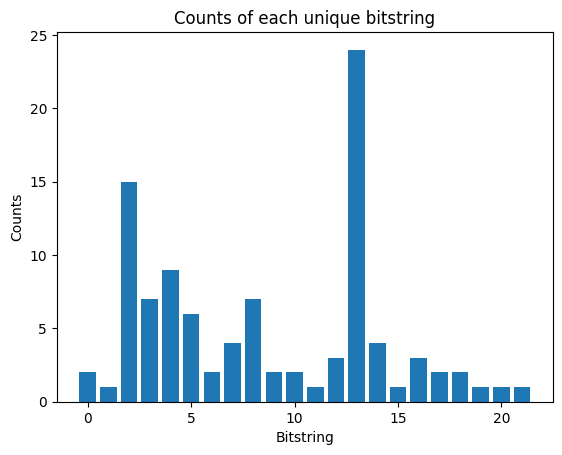

[(15, 10), (10, 0), (0, 0), (10, 10), (5, 0), (15, 0), (5, 5), (5, 0), (10, 0)]
[0, 0, 1, 1, 0, 1, 0, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


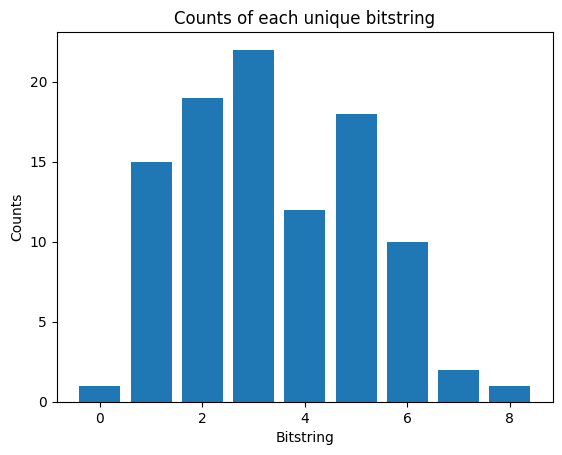

[(15, 10), (10, 0), (5, 0), (5, 5), (5, 0), (10, 0)]
[1, 0, 0, 1, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


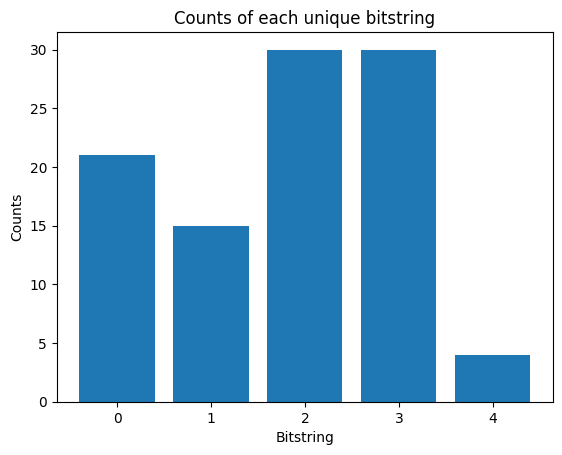

[(10, 0), (5, 0), (5, 0), (10, 0)]
[0, 0, 1, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


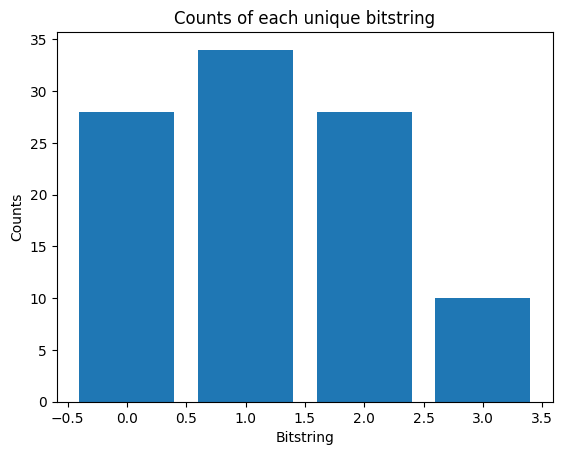

[(10, 0), (5, 0), (10, 0)]
[0, 1, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


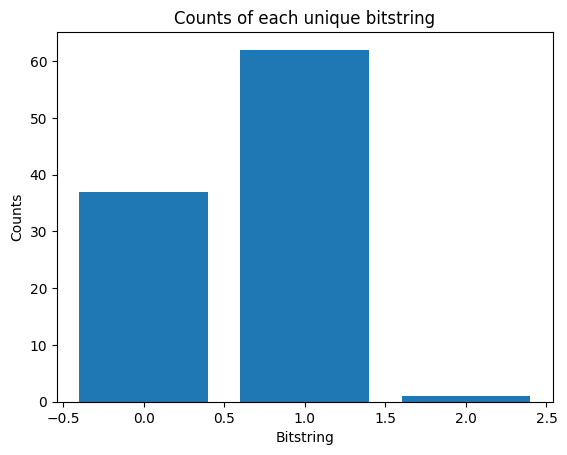

[(10, 0), (10, 0)]
[0, 1]
8.408964152537145


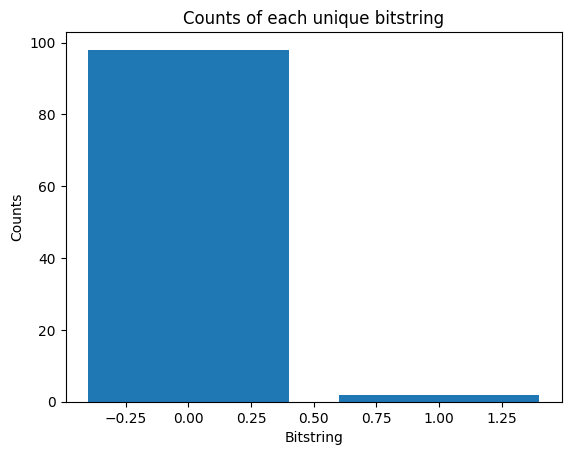

[(10, 0)]
[1]
[[(0, 0), (10, 10), (15, 0)], [(15, 10), (5, 5)], [(5, 0)], [(5, 0)], [(10, 0)], [(10, 0)]]


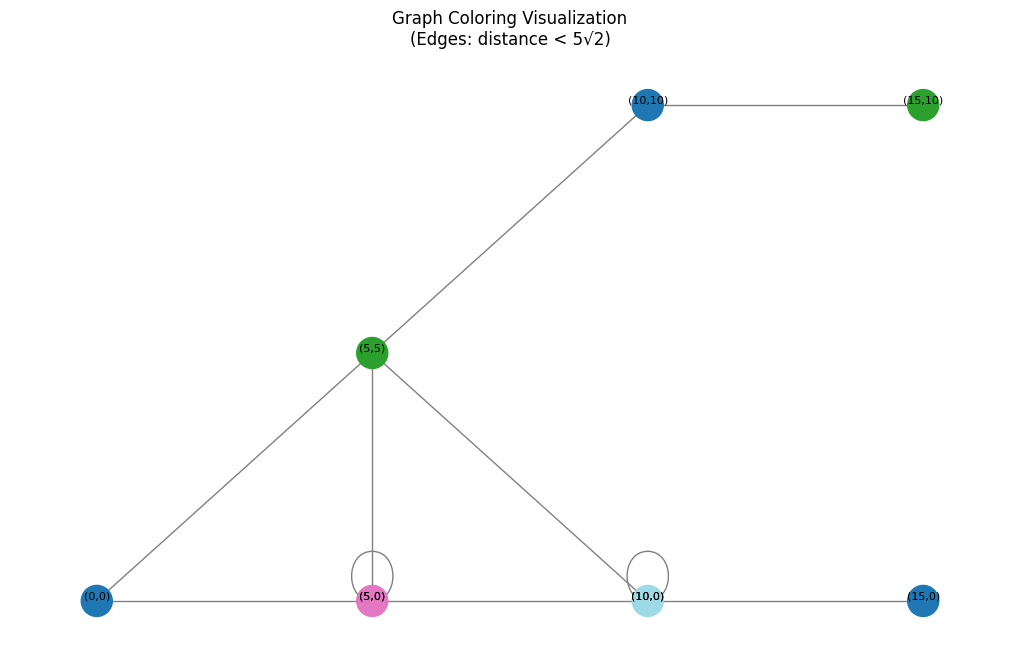

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


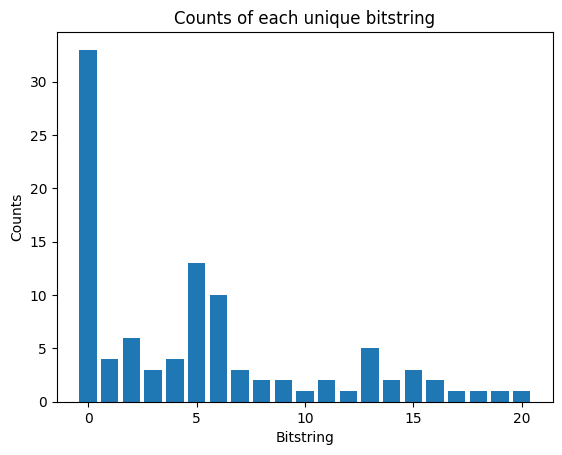

[(15, 15), (5, 0), (10, 5), (0, 15), (10, 0), (10, 15), (10, 5), (5, 15), (5, 10)]
[1, 1, 0, 1, 0, 0, 0, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


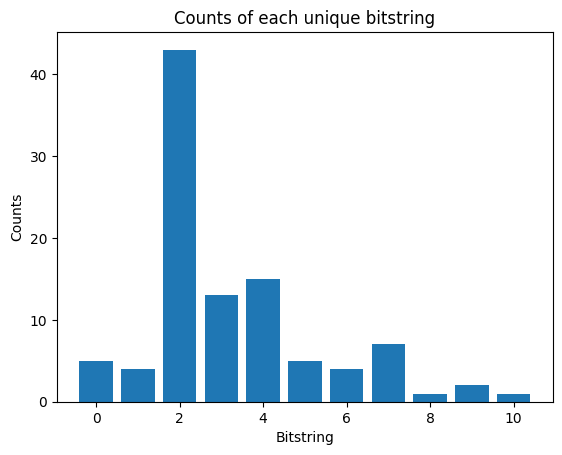

[(10, 5), (10, 0), (10, 15), (10, 5), (5, 15), (5, 10)]
[0, 1, 1, 0, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


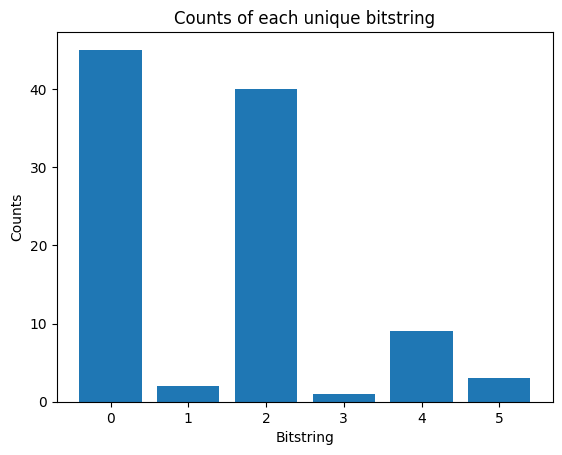

[(10, 5), (10, 5), (5, 15), (5, 10)]
[1, 0, 1, 0]
8.408964152537145


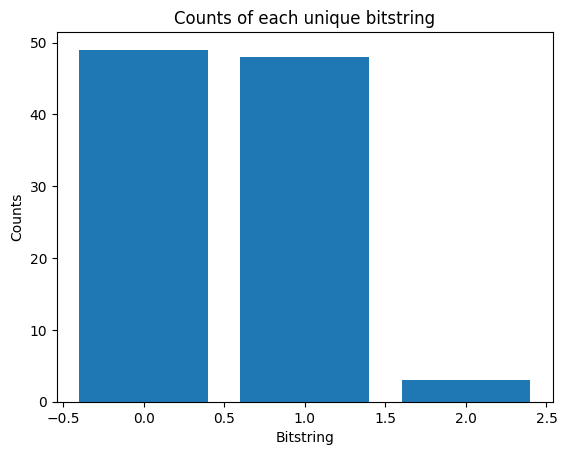

[(10, 5), (5, 10)]
[1, 0]
8.408964152537145


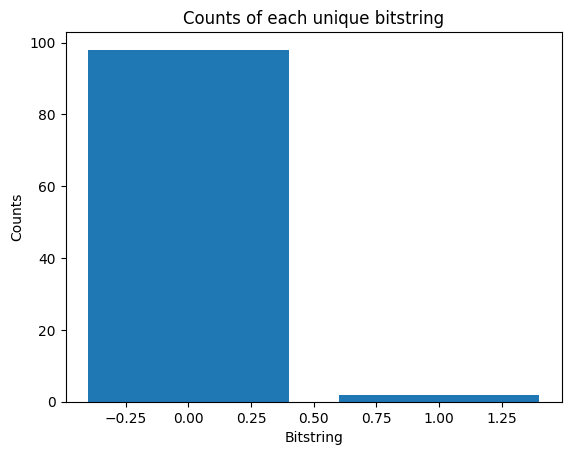

[(5, 10)]
[1]
[[(15, 15), (5, 0), (0, 15)], [(10, 0), (10, 15)], [(10, 5), (5, 15)], [(10, 5)], [(5, 10)]]


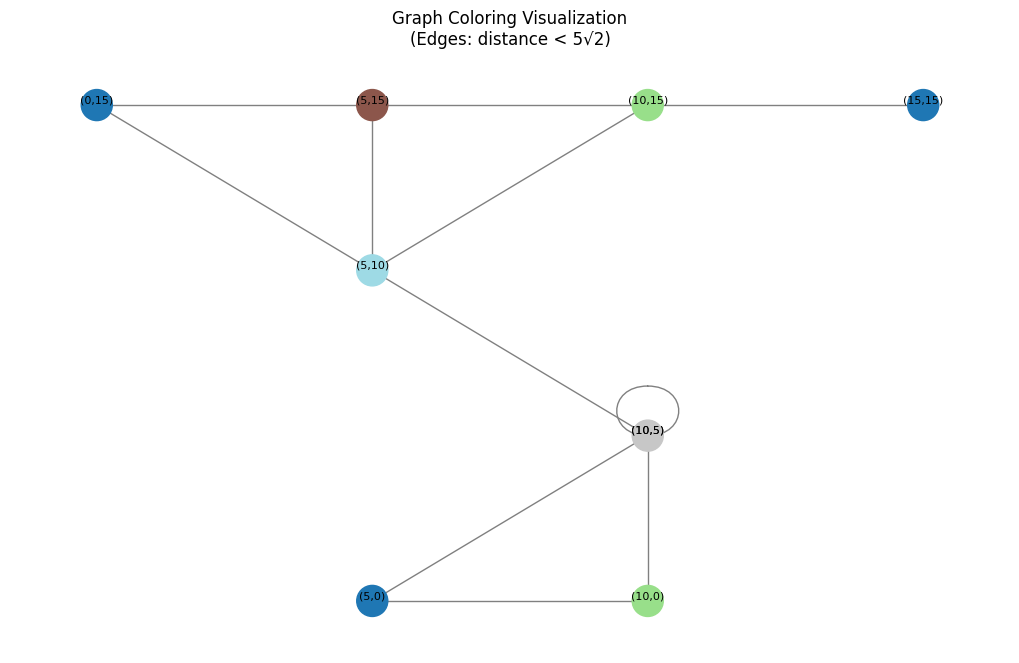

8.408964152537145


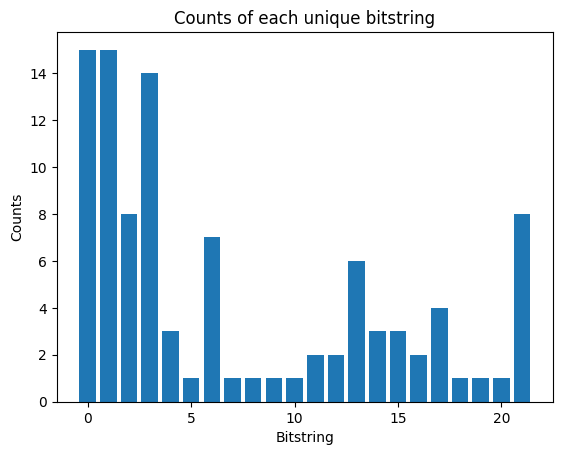

[(0, 10), (5, 5), (5, 0), (10, 15), (15, 15), (15, 10), (0, 5), (15, 0), (5, 10)]
[1, 0, 1, 1, 0, 0, 0, 1, 0]
8.408964152537145


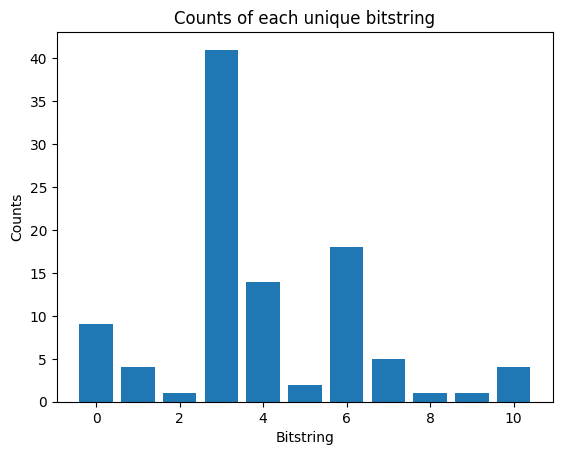

[(5, 5), (15, 15), (15, 10), (0, 5), (5, 10)]
[0, 1, 0, 1, 0]
8.408964152537145


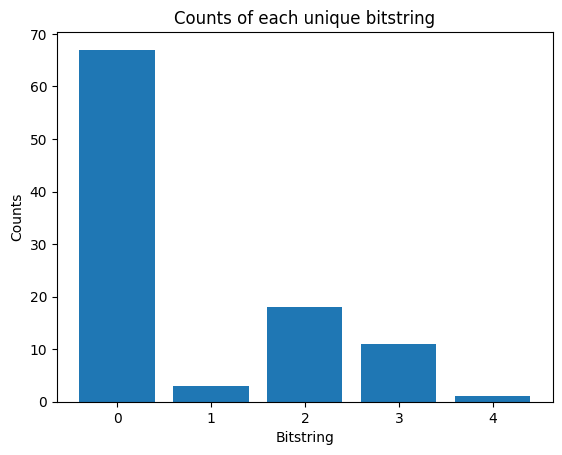

[(5, 5), (15, 10), (5, 10)]
[1, 1, 0]
8.408964152537145


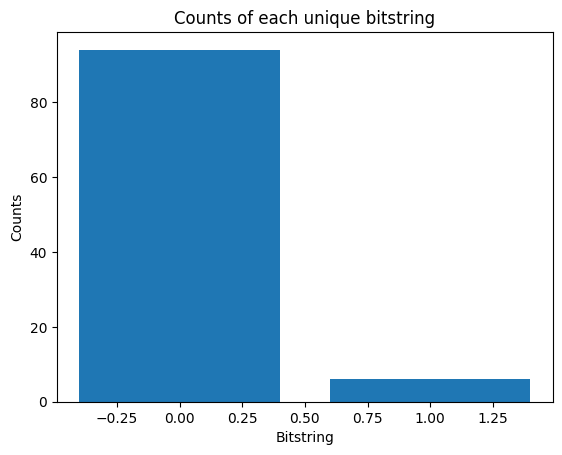

[(5, 10)]
[1]
[[(0, 10), (5, 0), (10, 15), (15, 0)], [(15, 15), (0, 5)], [(5, 5), (15, 10)], [(5, 10)]]


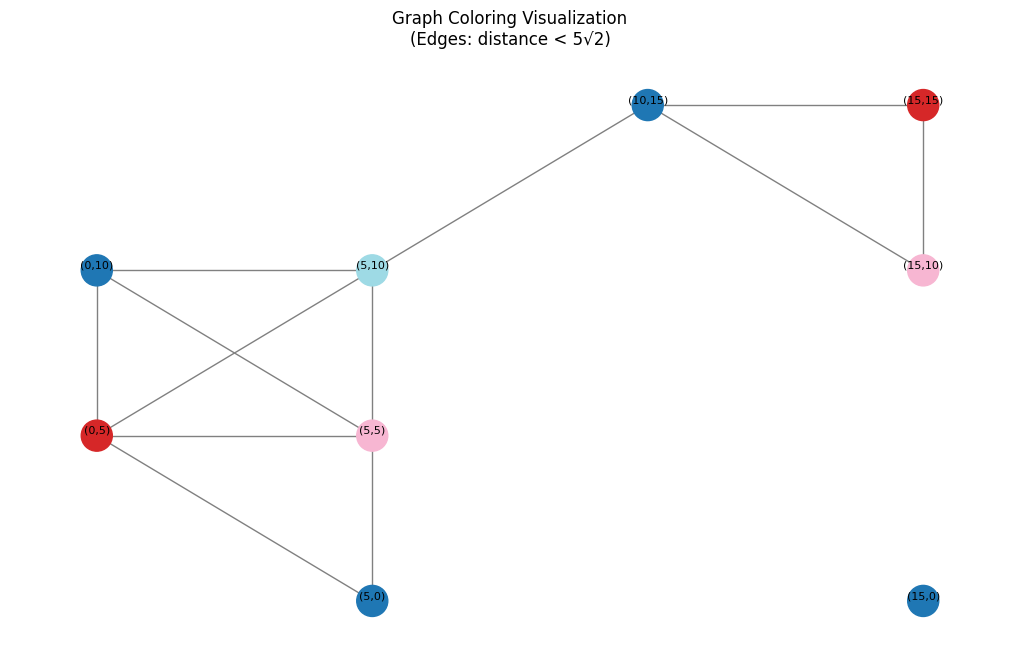

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


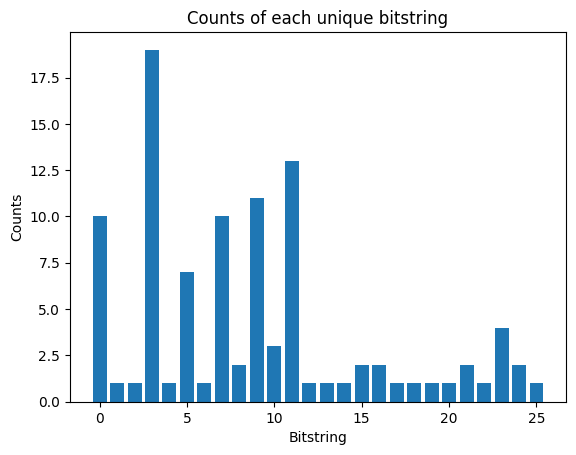

[(15, 0), (5, 0), (15, 10), (10, 15), (5, 0), (10, 15), (0, 10), (15, 5), (5, 10)]
[1, 1, 0, 1, 0, 0, 1, 0, 0]
8.408964152537145


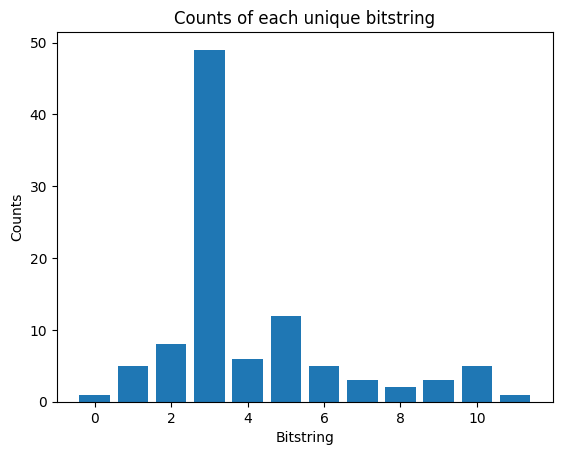

[(15, 10), (5, 0), (10, 15), (15, 5), (5, 10)]
[0, 1, 1, 1, 0]
8.408964152537145


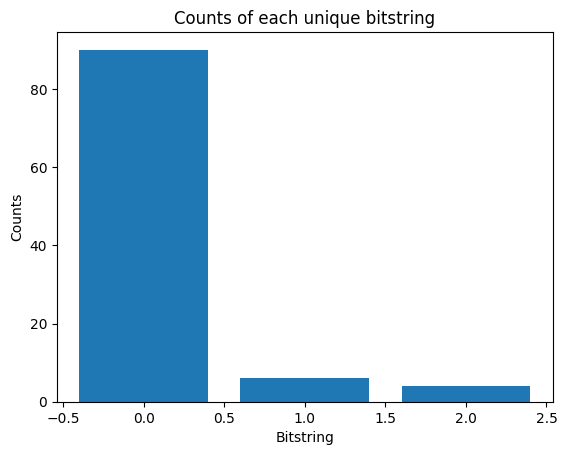

[(15, 10), (5, 10)]
[1, 1]
[[(15, 0), (5, 0), (10, 15), (0, 10)], [(5, 0), (10, 15), (15, 5)], [(15, 10), (5, 10)]]


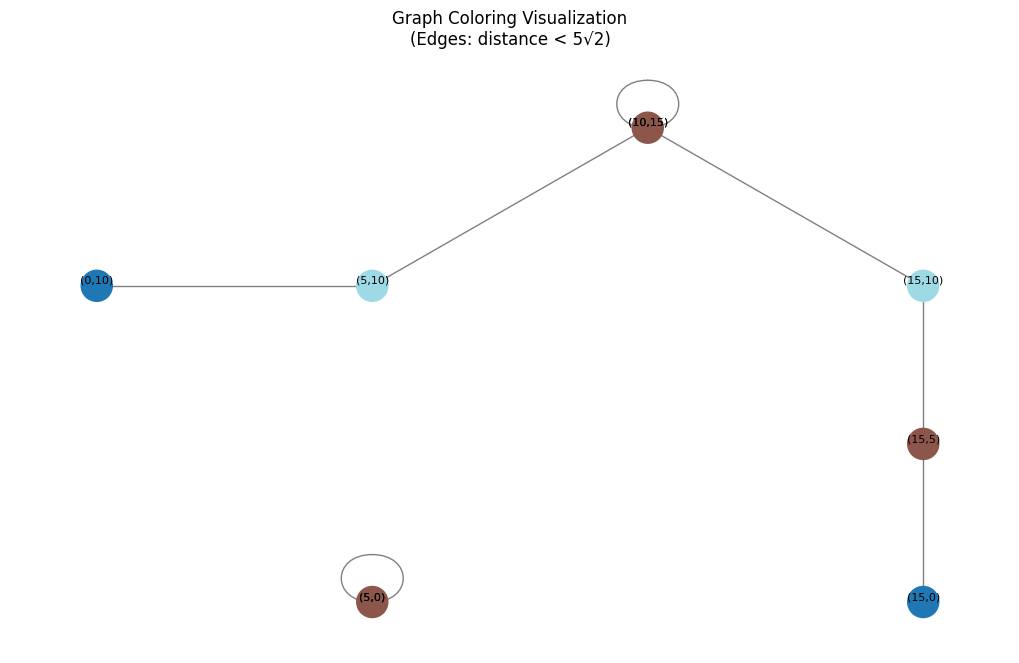

8.408964152537145


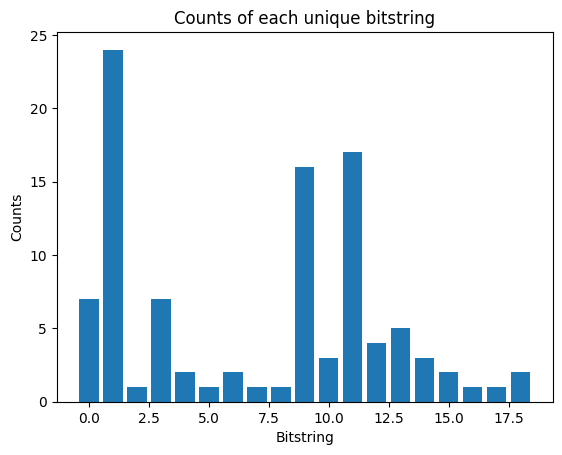

[(0, 0), (15, 10), (15, 5), (10, 0), (5, 15), (5, 5), (0, 5), (5, 0), (0, 15)]
[1, 1, 0, 1, 0, 0, 0, 0, 1]
8.408964152537145


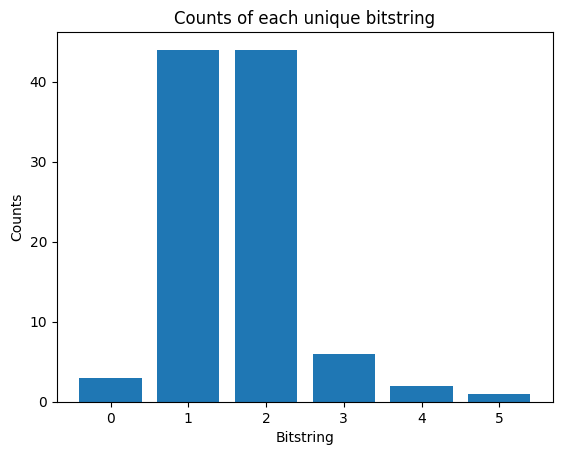

[(15, 5), (5, 15), (5, 5), (0, 5), (5, 0)]
[1, 1, 0, 1, 0]
8.408964152537145


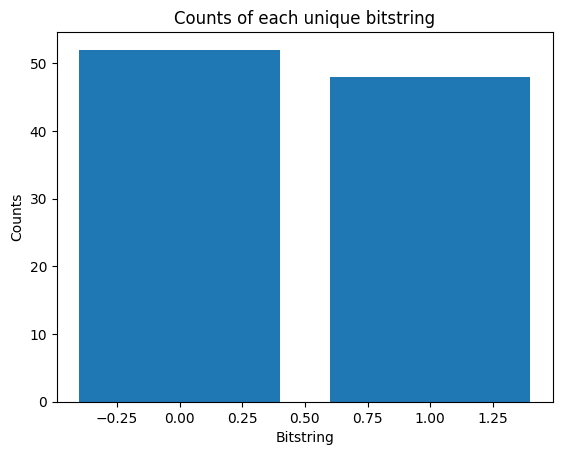

[(5, 5), (5, 0)]
[1, 0]
8.408964152537145


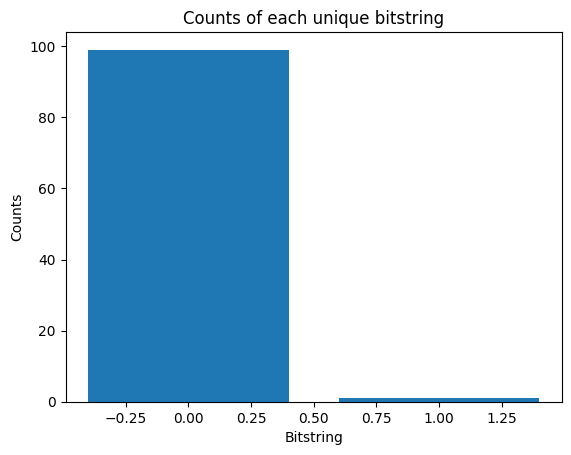

[(5, 0)]
[1]
[[(0, 0), (15, 10), (10, 0), (0, 15)], [(15, 5), (5, 15), (0, 5)], [(5, 5)], [(5, 0)]]


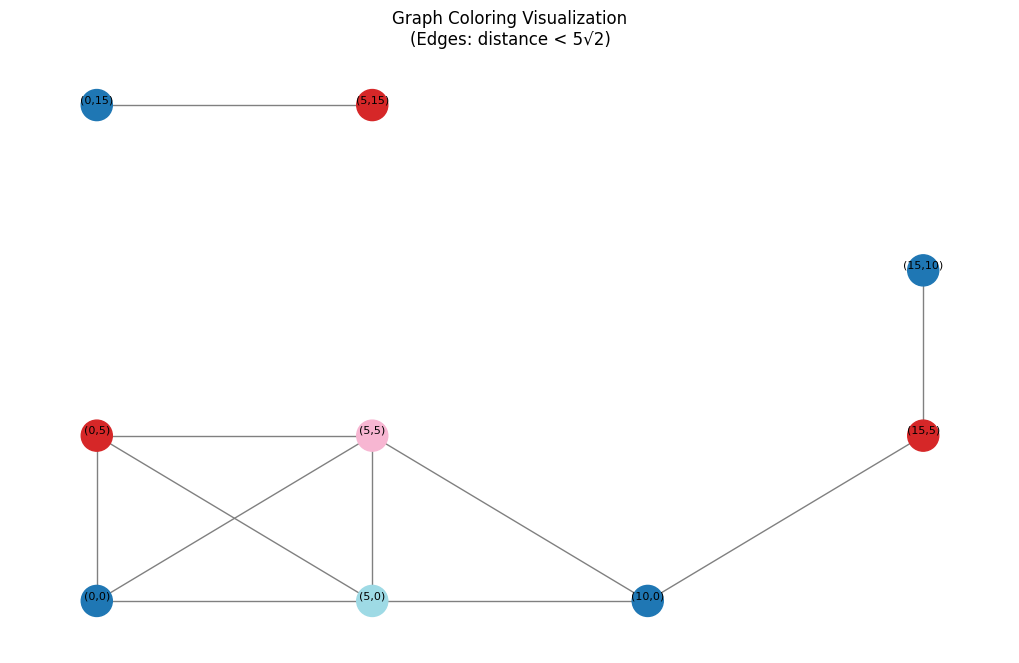

8.408964152537145


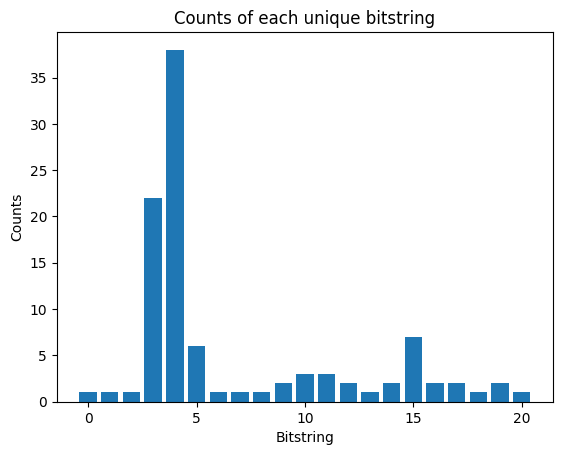

[(15, 15), (10, 5), (15, 0), (0, 15), (5, 0), (15, 10), (10, 0), (5, 10), (0, 5)]
[1, 0, 1, 1, 0, 0, 0, 0, 1]
8.408964152537145


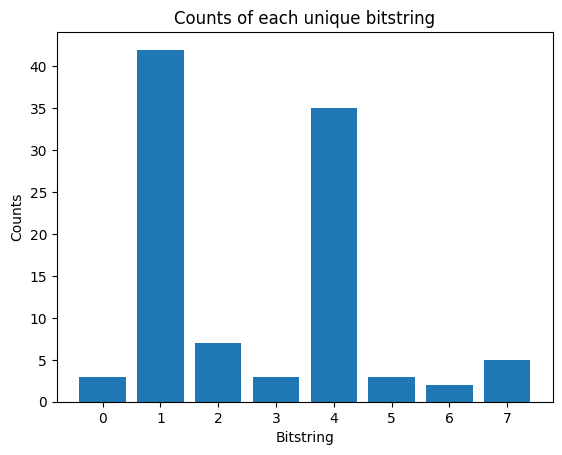

[(10, 5), (5, 0), (15, 10), (10, 0), (5, 10)]
[0, 1, 1, 0, 1]
8.408964152537145


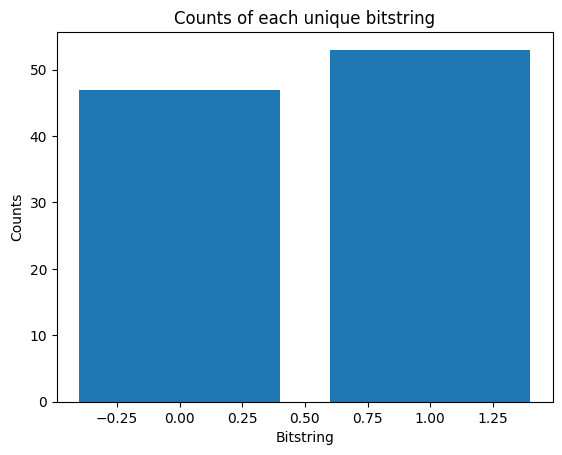

[(10, 5), (10, 0)]
[0, 1]
8.408964152537145


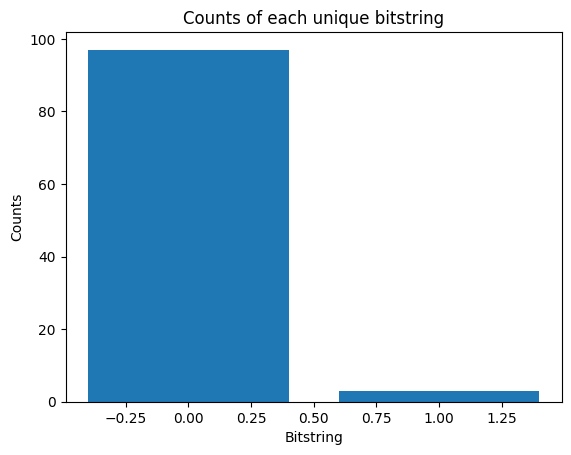

[(10, 5)]
[1]
[[(15, 15), (15, 0), (0, 15), (0, 5)], [(5, 0), (15, 10), (5, 10)], [(10, 0)], [(10, 5)]]


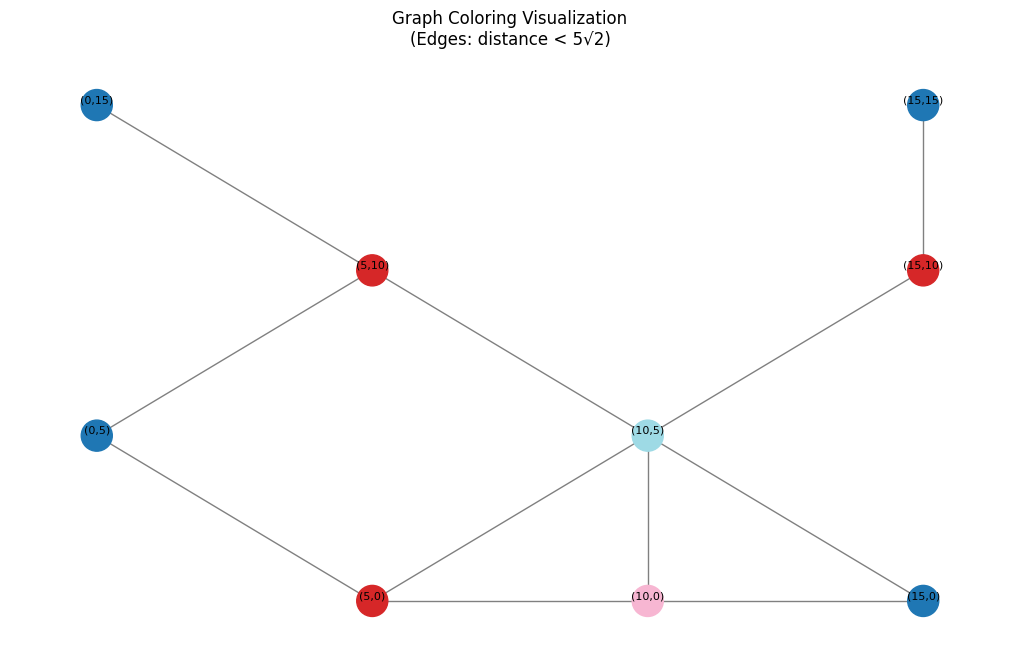

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


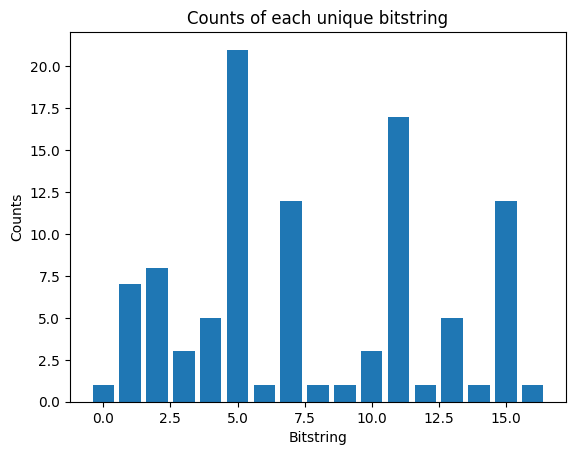

[(5, 5), (0, 15), (10, 5), (10, 0), (10, 10), (0, 15), (15, 10), (5, 10), (5, 5)]
[0, 1, 0, 1, 0, 0, 1, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


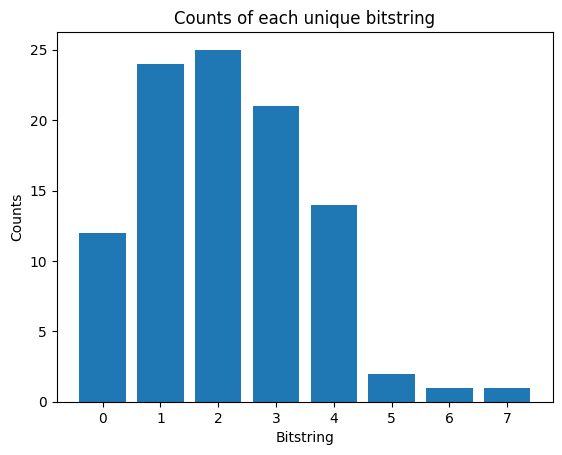

[(5, 5), (10, 5), (10, 10), (0, 15), (5, 10), (5, 5)]
[0, 0, 1, 1, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


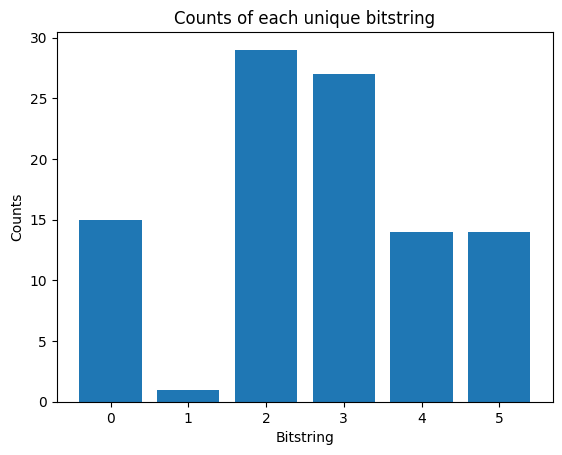

[(5, 5), (10, 5), (5, 10), (5, 5)]
[0, 1, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


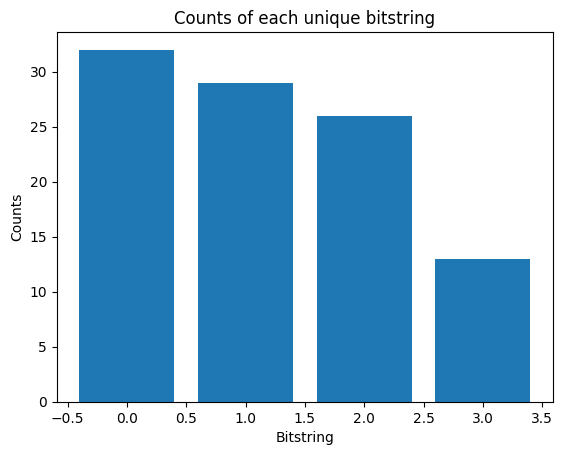

[(5, 5), (5, 10), (5, 5)]
[1, 0, 0]
8.408964152537145


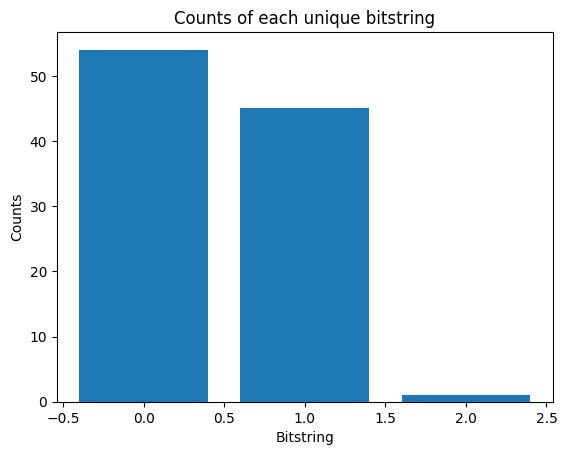

[(5, 10), (5, 5)]
[1, 0]
8.408964152537145


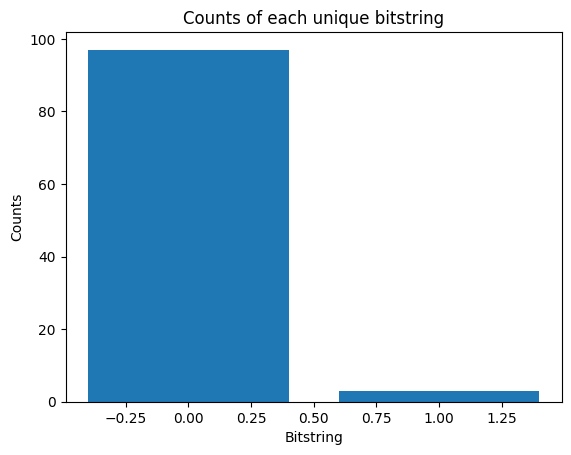

[(5, 5)]
[1]
[[(0, 15), (10, 0), (15, 10)], [(10, 10), (0, 15)], [(10, 5)], [(5, 5)], [(5, 10)], [(5, 5)]]


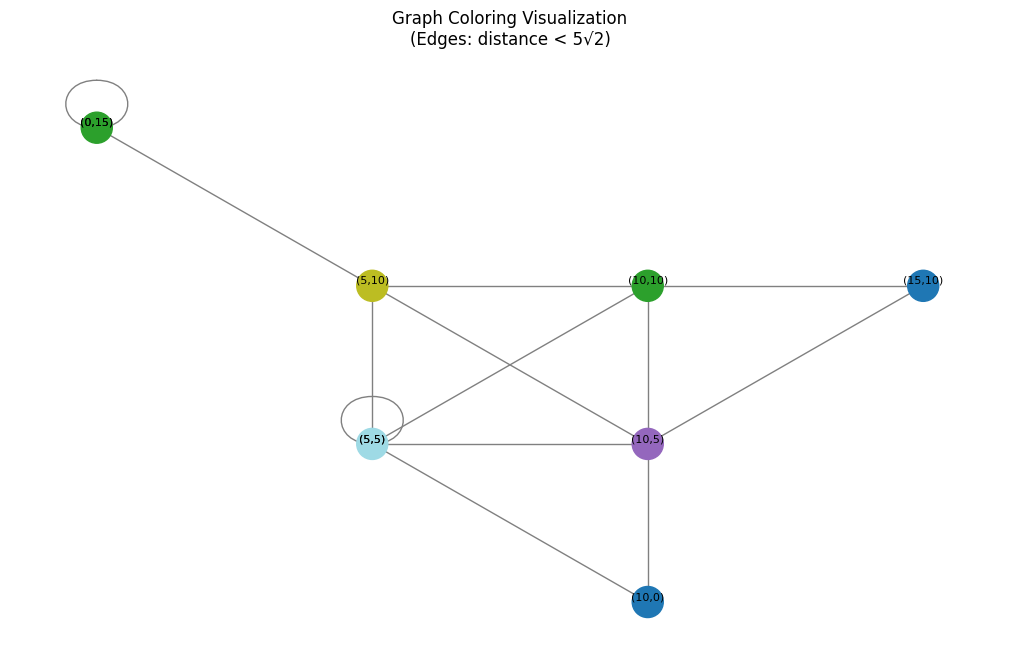

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


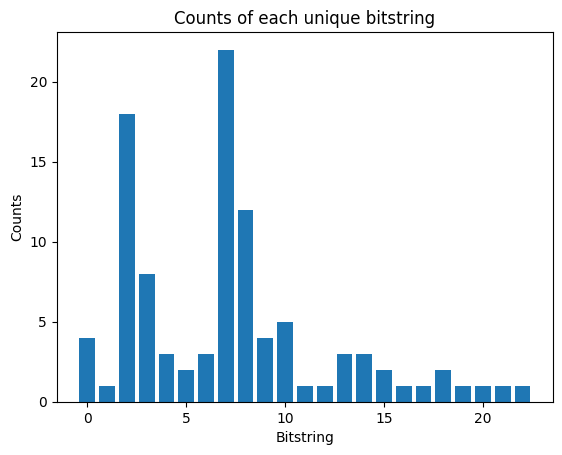

[(5, 10), (10, 0), (10, 5), (15, 0), (0, 0), (15, 0), (5, 0), (15, 10), (5, 0)]
[1, 0, 0, 0, 1, 1, 0, 1, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


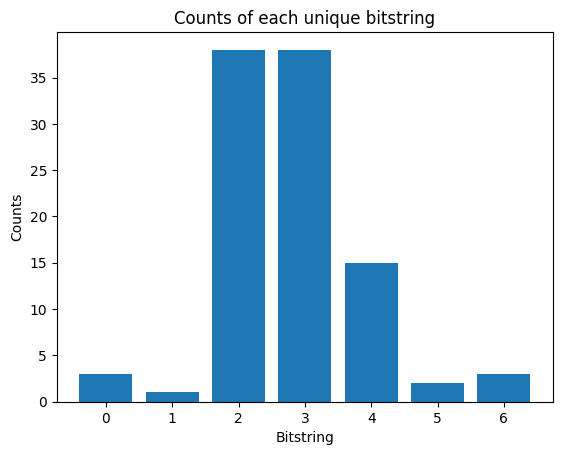

[(10, 0), (10, 5), (15, 0), (5, 0), (5, 0)]
[0, 0, 1, 1, 0]
8.408964152537145


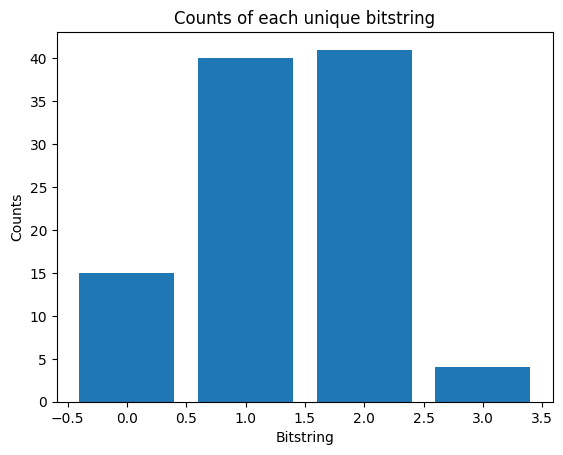

[(10, 0), (10, 5), (5, 0)]
[0, 0, 1]
8.408964152537145


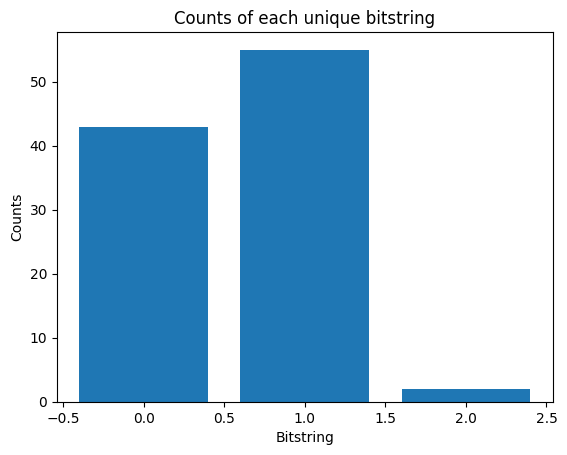

[(10, 0), (10, 5)]
[0, 1]
8.408964152537145


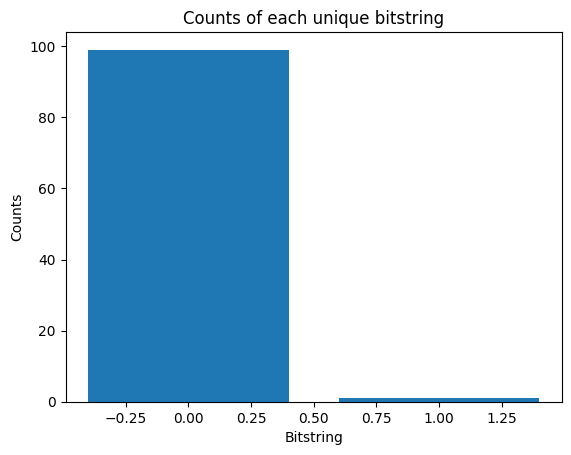

[(10, 0)]
[1]
[[(5, 10), (0, 0), (15, 0), (15, 10)], [(15, 0), (5, 0)], [(5, 0)], [(10, 5)], [(10, 0)]]


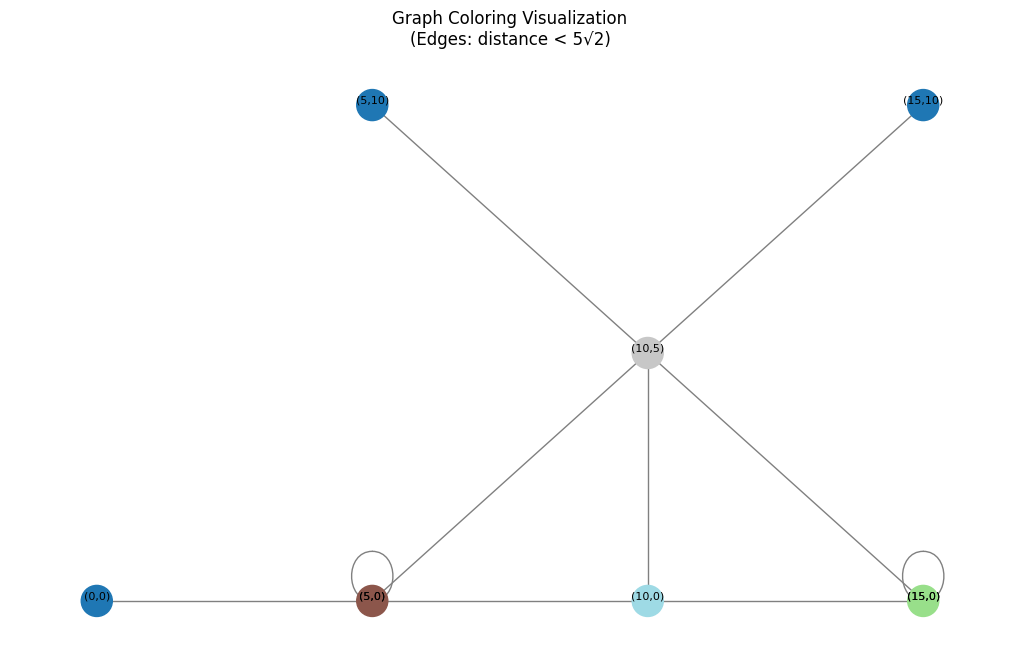

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


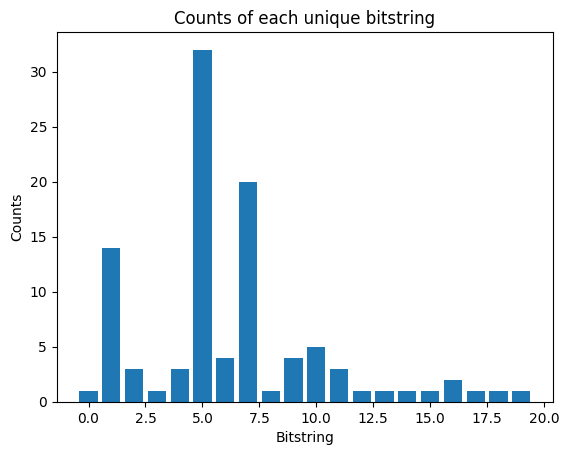

[(5, 0), (15, 15), (5, 10), (10, 0), (5, 15), (5, 10), (10, 10), (0, 0), (5, 0)]
[0, 1, 0, 1, 1, 0, 0, 1, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


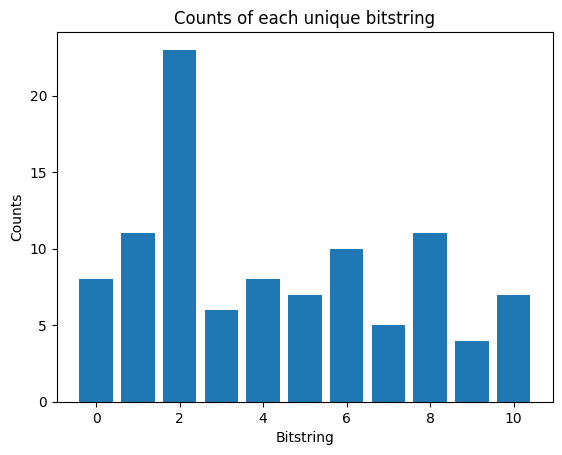

[(5, 0), (5, 10), (5, 10), (10, 10), (5, 0)]
[1, 0, 0, 1, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


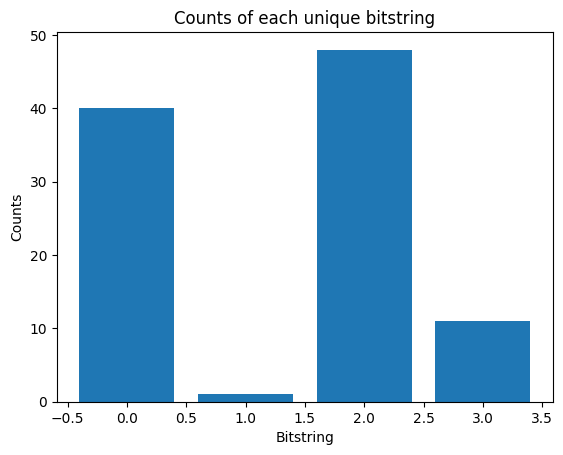

[(5, 10), (5, 10), (5, 0)]
[0, 1, 1]
8.408964152537145


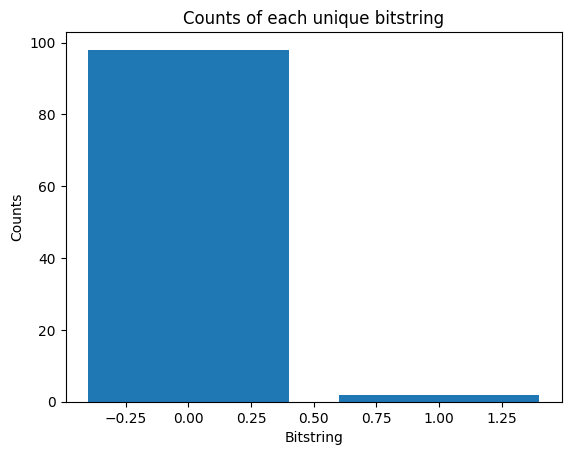

[(5, 10)]
[1]
[[(15, 15), (10, 0), (5, 15), (0, 0)], [(5, 0), (10, 10)], [(5, 10), (5, 0)], [(5, 10)]]


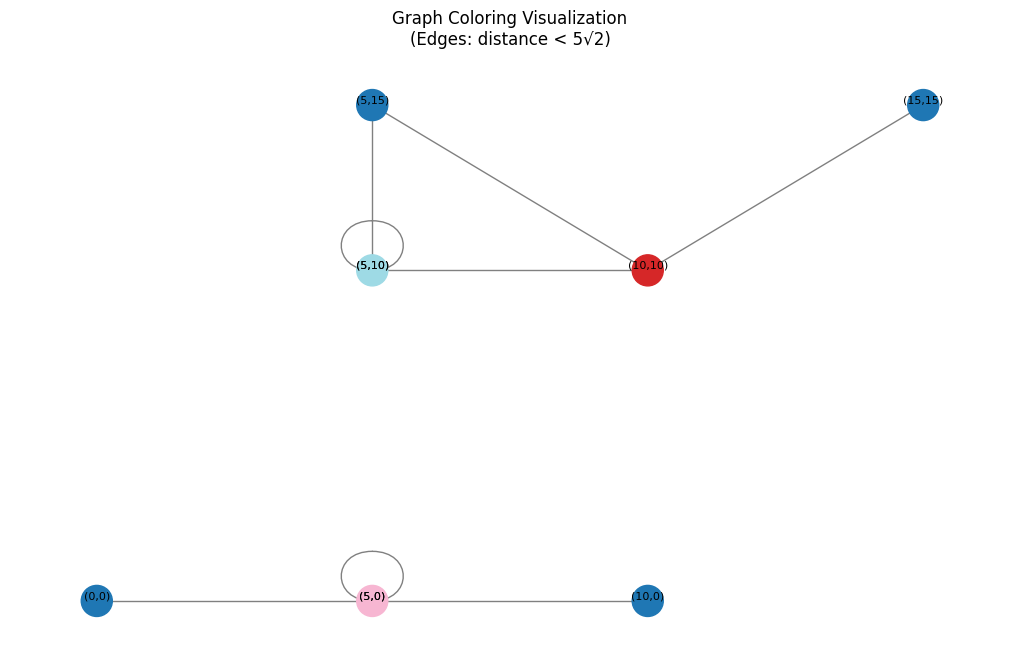

In [ ]:

# main
import random

# points = [(0,0), (1,0), (0,1), (0,2), (1,3), (2,0), (2,2), (2,3), (3,0),(3,1), (3,2), (3,3)]
# Initial Points
og_points = [(0,0), (1,0), (0,1), (0,2), (3,2), (3,3)]
og_points = [(0,0), (1,0), (0,1), (0,2), (1,3), (2,0), (2,2), (2,3), (3,0),(3,1), (3,2), (3,3)]
# og_points = [(9.0, 0.0), (9.0, 9.0), (9.0, 22.5), (4.5, 4.5), (9.0, 31.5), (4.5, 18.0), (4.5, 27.0), (4.5, 40.5), (0.0, 13.5), (9.0, 49.5), (0.0, 27.0), (0.0, 36.0), (9.0, 58.5), (0.0, 45.0), (0.0, 54.0), (4.5, 63.0)]
# og_points = [(2.0, 0.0), (2.0, 2.0), (2.0, 5.0), (1.0, 1.0), (2.0, 7.0), (1.0, 4.0), (1.0, 6.0), (1.0, 9.0), (0.0, 3.0), (2.0, 11.0), (0.0, 6.0), (0.0, 8.0), (2.0, 13.0)] #, (0.0, 10.0), (0.0, 12.0), (1.0, 14.0)]
og_points =[(0, 7),(1, 7),(2, 6),(3, 4),(3, 7),(4, 7),(5, 7),(8, 7),(7, 6),(6, 5),(8, 4),(8, 2),(8, 5),(8, 0),(4, 2),(5, 4)]
#

unit_tests = []

for i in range(10):
    unit_tests.append([(random.randint(0, 3), random.randint(0, 3)) for _ in range(9)])

for test in unit_tests:
    a = 5
    # a = 1 # a;ready scaled here

    # mul;tiply all the points x5 
    og_points = test
    og_points = [(x*a,y*a) for x,y in og_points] #TODO add back

    points = og_points.copy()
    coloring = []

    while points:
        remaining_set, max_set = run_rydberg(points)
        points = remaining_set
        coloring.append(max_set)

    # plot then colored graph
    # fig, ax = plt.subplots()
    print(coloring)
    visualize_colored_groups(coloring)

In [11]:
example_data = [[(0, 0), (0, 5), (15, 10)], [(5, 0), (0, 10), (15, 15)]]

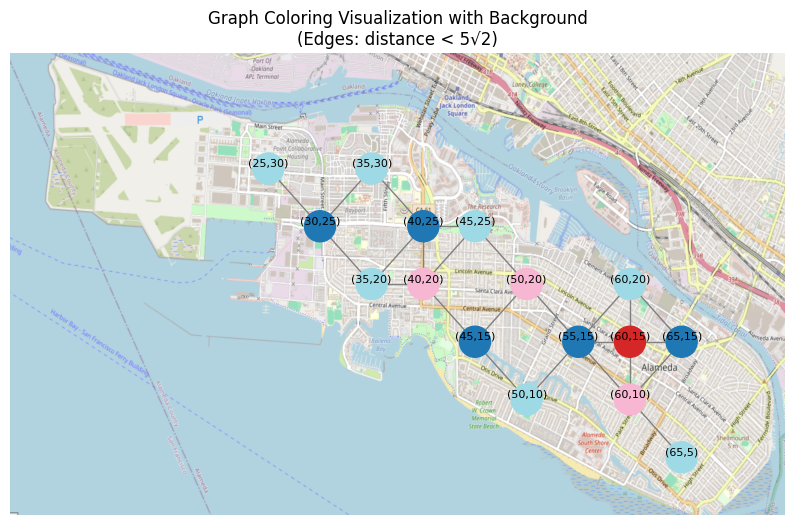

In [106]:
import random

def visualize_colored_groups_with_background(data, background_image_path, shift_x=0, shift_y=0):
    """
    Visualize colored groups of points overlaid on a background image with optional x and y-axis shifts.

    Args:
        data: List of groups of points (e.g., [[(x1, y1), (x2, y2)], [(x3, y3), ...]]).
        background_image_path: Path to the background image.
        shift_x: Value to shift all x-coordinates to the right (default is 0).
        shift_y: Value to shift all y-coordinates upward (default is 0).
    """
    # Shuffle the order of groups to randomize color assignment
    random.shuffle(data)

    # Load the background image
    img = mpimg.imread(background_image_path)
    
    # Create graph and calculate edges
    G = nx.Graph()
    all_points = [point for group in data for point in group]
    
    # Shift all coordinates by shift_x and shift_y
    shifted_points = [(x + shift_x, y + shift_y) for x, y in all_points]
    
    # Add nodes with position attributes
    for point in shifted_points:
        G.add_node(point, pos=point)
    
    # Create edges based on distance threshold
    threshold = 5 * math.sqrt(2)
    for (p1, p2) in combinations(shifted_points, 2):
        distance = math.hypot(p1[0] - p2[0], p1[1] - p2[1])
        if distance <= threshold:
            G.add_edge(p1, p2)
    
    # Create color mapping
    color_map = []
    color_dict = {}
    for color_idx, group in enumerate(data):
        for point in group:
            shifted_point = (point[0] + shift_x, point[1] + shift_y)
            color_dict[shifted_point] = color_idx
    
    # Create ordered color list based on node order
    for node in G.nodes():
        color_map.append(color_dict[node])
    
    # Draw the graph
    pos = nx.get_node_attributes(G, 'pos')
    plt.figure(figsize=(10, 6))
    
    # Display the background image
    plt.imshow(img, extent=[0, max(p[0] for p in shifted_points) + 10, 0, max(p[1] for p in shifted_points) + 10], aspect='auto')
    
    # Overlay the graph
    nx.draw(G, pos, 
            node_color=color_map, 
            cmap=plt.cm.tab20,
            with_labels=False,
            node_size=500,
            edge_color='gray')
    
    # Add coordinate labels
    for point in shifted_points:
        plt.text(point[0], point[1], f"({point[0]},{point[1]})", 
                 ha='center', va='bottom', fontsize=8)
    
    plt.title("Graph Coloring Visualization with Background\n(Edges: distance < 5√2)")
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage
visualize_colored_groups_with_background(coloring, "/opt/extra/avijit/projects/rlof/Ryan_2025/YQH/city.png", shift_x=25, shift_y=5)

Loading BokehJS ...

Running 10 trials with 10 shots each...
Running 10 trials with 50 shots each...
Running 10 trials with 100 shots each...
Running 10 trials with 200 shots each...
Running 10 trials with 500 shots each...
Running 10 trials with 1000 shots each...


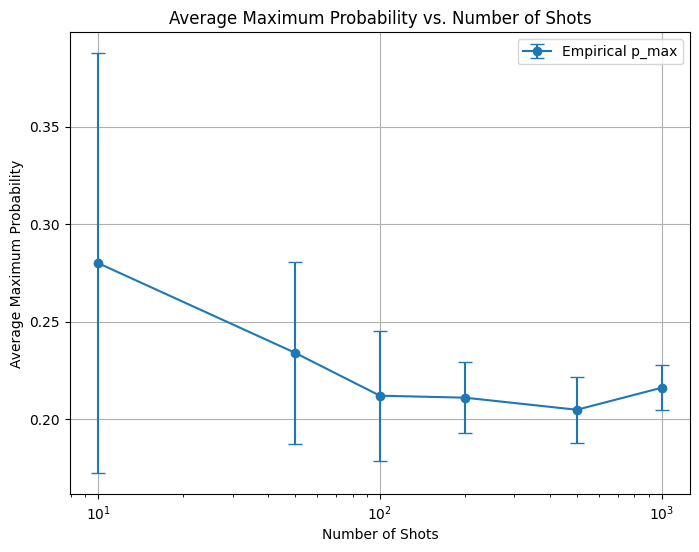

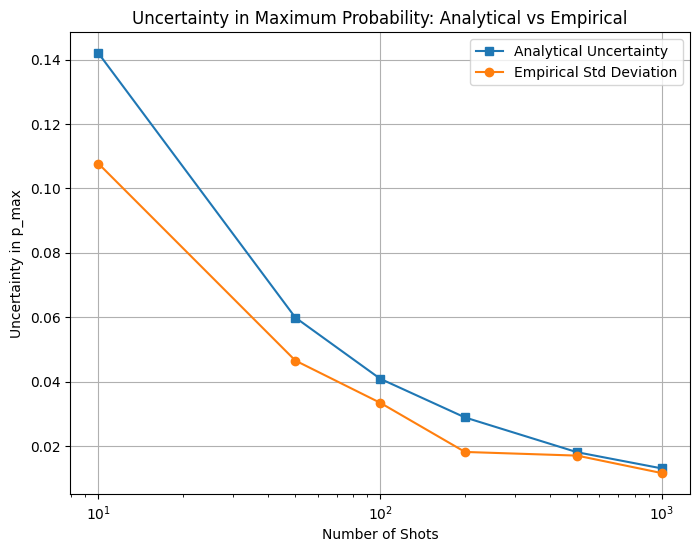

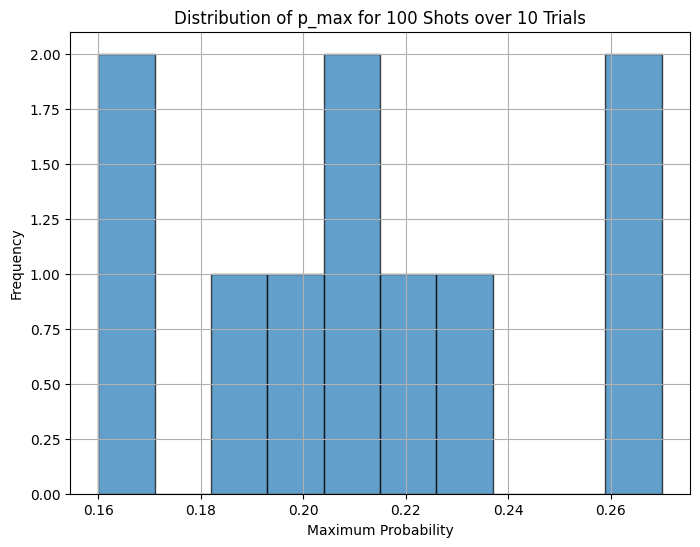

In [110]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Import required functions from bloqade and other libraries
from bloqade.analog import load, save, start, get_capabilities, piecewise_linear
from bloqade.analog.atom_arrangement import Square
from bokeh.io import output_notebook
output_notebook() 

# Create data folder if needed
if not os.path.isdir("data"):
    os.mkdir("data")

# Set seed for reproducibility
rng = np.random.default_rng(1234)

# Global parameter (as in your original code)
a = 5

# Define the points used in the experiment.
# Here we reuse your original set of points.
og_points = [(8, 0), (7, 1), (5, 1), (8, 2), (4, 2), (7, 2), (5, 3), (3, 3), (7, 3), (2, 3),
             (6, 2)] #(4, 4), (1, 4), (3, 4), (2, 5), (0, 5)]
# Scale by parameter a
points = [(x * a, y * a) for x, y in og_points]

# ============================================================================
# Function to run the Rydberg simulation and return the maximum measured probability.
# This function mimics the core of your "run_rydberg" function, but is modified 
# to accept a variable number of shots and to return the metric of interest.
# ============================================================================
def get_max_probability(points, shots):
    """
    Runs the Rydberg experiment with the given points and shot count,
    then returns the maximum measured probability (max count / shots).

    Parameters:
      points : list of tuples
          The positions of the atoms.
      shots : int
          Number of shots (measurements) to run.

    Returns:
      p_max : float
          The maximum probability among all unique bitstring outcomes.
    """
    # Set up the geometry
    geometry = start.add_position(points)
    
    # Get capabilities from the backend (e.g., Aquila)
    aquila_capabilities = get_capabilities()
    C6 = float(aquila_capabilities.capabilities.rydberg.c6_coefficient)
    Omega_max = float(aquila_capabilities.capabilities.rydberg.global_.rabi_frequency_max)
    
    # Compute Rydberg blockade radius-related parameters 
    Rba = np.power(2, 3/4)
    Rb = Rba * a  
    # Final detuning value:
    Delta_end = C6 / (Rb**6)
    
    # Time parameters for the pulse protocols
    T_max = 4
    sweep_time = 0.8 * T_max  # duration of the main sweep
    ramp_time = 0.1 * T_max   # duration of the ramps
    
    # Define the protocols for Rabi amplitude and detuning
    rabi_amplitude_values = [0.0, Omega_max, Omega_max, 0.0]
    detuning_values = [-Delta_end, -Delta_end, Delta_end, Delta_end]
    durations = [ramp_time, sweep_time, ramp_time]
    
    RabiProtocol = piecewise_linear(durations, rabi_amplitude_values)
    DeltaProtocol = piecewise_linear(durations, detuning_values)
    
    # Build the experimental program for the geometry
    mis_udg_program = (
        geometry.rydberg.rabi.amplitude.uniform.apply(RabiProtocol)
        .detuning.uniform.apply(DeltaProtocol)
    )
    
    # Run the simulation with the specified number of shots
    result = mis_udg_program.bloqade.python().run(shots, interaction_picture=True)
    
    # Retrieve the measurement data; assume bitstrings is a list/array of measurement outcomes
    data = result.report().bitstrings()
    # Note: data[0] is assumed to contain a 2D array of bitstrings (each row is one outcome)
    bitstrings, counts = np.unique(data[0], axis=0, return_counts=True)
    
    # Determine the maximum count among the outcomes and compute the corresponding probability
    max_count = np.max(counts)
    p_max = max_count / shots
    
    return p_max

# ============================================================================
# Experiment: Vary the number of shots, run multiple trials for each,
# then calculate average maximum probability and its empirical uncertainty.
# Also compute an analytical uncertainty (using sqrt(p*(1-p)/shots)).
# ============================================================================
# Specify the shot counts to test and the number of repeated trials per shot count
shot_counts = [10, 50, 100, 200, 500, 1000]
n_trials = 10

# Dictionaries to store the results for each shot count
empirical_pmax = {}  # list of p_max values per shot count
for shots in shot_counts:
    trial_results = []
    print(f"Running {n_trials} trials with {shots} shots each...")
    for trial in range(n_trials):
        p_max = get_max_probability(points, shots)
        trial_results.append(p_max)
    empirical_pmax[shots] = trial_results

# Compute statistics: mean and standard deviation for the maximum probability
mean_pmax = []
std_pmax = []
analytical_uncertainty = []  # using sqrt(p*(1-p)/shots)
for shots in shot_counts:
    p_array = np.array(empirical_pmax[shots])
    mean_val = p_array.mean()
    std_val = p_array.std()
    mean_pmax.append(mean_val)
    std_pmax.append(std_val)
    
    # For analytical uncertainty assume the "true" p is estimated by the mean value.
    analytical_uncertainty.append(np.sqrt(mean_val * (1 - mean_val) / shots))

# ============================================================================
# Visualization
# ============================================================================
# Chart 1: Average maximum probability vs. number of shots (with error bars)
plt.figure(figsize=(8, 6))
plt.errorbar(shot_counts, mean_pmax, yerr=std_pmax, fmt='o-', capsize=5, label='Empirical p_max')
plt.xlabel("Number of Shots")
plt.ylabel("Average Maximum Probability")
plt.title("Average Maximum Probability vs. Number of Shots")
plt.xscale('log')  # log-scale for shot counts if desired
plt.legend()
plt.grid(True)
plt.show()

# Chart 2: Comparison of empirical uncertainty with analytical uncertainty
plt.figure(figsize=(8, 6))
plt.plot(shot_counts, analytical_uncertainty, 's-', label='Analytical Uncertainty')
plt.plot(shot_counts, std_pmax, 'o-', label='Empirical Std Deviation')
plt.xlabel("Number of Shots")
plt.ylabel("Uncertainty in p_max")
plt.title("Uncertainty in Maximum Probability: Analytical vs Empirical")
plt.xscale('log')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Additional Chart: Distribution of p_max for selected shot count(s)
# For example, for 100 shots, show a histogram of p_max from the trials.
selected_shots = 100
plt.figure(figsize=(8, 6))
plt.hist(empirical_pmax[selected_shots], bins=10, edgecolor='k', alpha=0.7)
plt.xlabel("Maximum Probability")
plt.ylabel("Frequency")
plt.title(f"Distribution of p_max for {selected_shots} Shots over {n_trials} Trials")
plt.grid(True)
plt.show()
